In [1]:
import platform
platform.platform()

'macOS-26.2-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import os
sys.path.append(os.path.abspath("../.."))

In [4]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [5]:
import matplotlib.pyplot as plt

In [6]:
import pandas as pd
pd.__version__

'2.3.3'

In [7]:
from rdkit import rdBase, Chem
rdBase.rdkitVersion

'2023.09.1'

In [8]:
from rdkit.Chem import Draw

In [9]:
from SSMetrics import metrics

In [10]:
df1 = pd.read_csv("../../1_dataset/1_28descriptors/1_dataset/2_standardization/standardized_dataset.csv")
df1.shape

(4665, 37)

In [11]:
df1.columns

Index(['SMILES', 'InChI', 'InChIKey', 'K3FeCN6', 'MesAcr+BF4-', 'CuCl',
       'Diacetyl', 'T(p-OMe)PPCo', 'Electrode', 'm_1_L', 'm_1_B1', 'm_1_B5',
       'p_L', 'p_B1', 'p_B5', 'm_2_L', 'm_2_B1', 'm_2_B5', 'o_L', 'o_B1',
       'o_B5', 'Charge_O', 'Charge_next_O', 'Charge_o_1', 'Charge_m_1',
       'Charge_p', 'Charge_m_2', 'Charge_o_2', 'HOMO', 'MolLogP', 'MolWt',
       'num_N', 'num_O', 'num_S', 'num_F', 'num_Cl', 'num_Br'],
      dtype='object')

In [12]:
conditions = [["K3FeCN6",(255/255, 75/255, 0/255), "K$_3$[Fe(CN)$_6$]"],
              ["MesAcr+BF4-", (153/255, 0/255, 153/255), "MesAcr$^+$BF$_4^-$"],
              ["CuCl", (3/255, 175/255, 122/255), "CuCl"],
              ["Diacetyl", (246/255, 170/255, 0/255), "Diacetyl"],
              ["T(p-OMe)PPCo", (77/255, 196/255, 255/255), "T($p$-OMe)PPCo"],
              ["Electrode", (255/255, 128/255, 130/255), "Electrode"]]

In [13]:
li_numbers = []
li_distance_avg = []
li_distance_max = []
li_details = []

In [14]:
for i in range(6):
    condition = conditions[i][0]
    
    print(f"\n{condition}")
    df2 = df1[df1[condition] == 1]

    n = len(df2)
    li_numbers.append(n)

    ss = metrics.metrics_distance(df2)
    li_distance_avg.append(ss[2])
    li_distance_max.append(ss[4])
    li_details.append(ss[6])
    
    ss[6].to_csv(f"{condition}.csv")


K3FeCN6
Average coordinate: (-0.28998527310377326, -0.34184648887689917, -0.28452003826526895, 0.07608248576202803, 0.16382226085833837, -0.021152344199925028, -0.3069629710246107, -0.34917993644576284, -0.3119155677637267, -0.37895348564502734, 0.15998133710517748, -0.4862221385039799, 0.05248744680345803, -1.228779376748825, 0.7042814959805546, -0.6133128091948532, 1.3273666226376006, -0.6879881312129842, 0.5569748434157349, 0.5589710630064243, -0.6188973821745486, -1.3568595606257126, -1.1647585195490282, -0.446232407987549, -0.3803344302566363, -0.2116436181306902, -0.39683608990092506, -0.3518791269209797)
Sum of distances: 64.78614307926608
Distance_avg: 2.816788829533308
Nearest SMILES: Cc1ccc(O)c(C)c1
Distance_max: 5.054440854194798
Farthest SMILES: CC(C)(C)c1ccc(O)c(C(C)(C)C)c1

Describe
count    23.000000
mean      2.816789
std       0.798559
min       1.735708
25%       2.221011
50%       2.724590
75%       3.103078
max       5.054441
Name: 23, dtype: float64

MesAcr+BF4-
A

In [15]:
labels = []

for i in range(6):
    labels.append(f"{conditions[i][2]} ({li_numbers[i]})")
    
labels

['K$_3$[Fe(CN)$_6$] (23)',
 'MesAcr$^+$BF$_4^-$ (20)',
 'CuCl (19)',
 'Diacetyl (12)',
 'T($p$-OMe)PPCo (9)',
 'Electrode (9)']

In [16]:
li_details_2 = []
for i in range(6):
    avg_i = len(li_details[i]) - 1
    df = li_details[i].sort_values(avg_i, ascending=False, ignore_index=True)

    li = df[avg_i].to_list()
    li_details_2.append(li[:-1])

    condition = conditions[i][0]
    smiles1 = df["SMILES"][0]
    print(smiles1)
    Draw.MolToFile(Chem.MolFromSmiles(smiles1),
                    f"{condition}_1.png",
                    size=(600,300))

    smiles2 = df["SMILES"][1]
    print(smiles2)
    Draw.MolToFile(Chem.MolFromSmiles(smiles2),
                    f"{condition}_2.png",
                    size=(600,300))

    smiles3 = df["SMILES"][2]
    print(smiles3)
    Draw.MolToFile(Chem.MolFromSmiles(smiles3),
                    f"{condition}_3.png",
                    size=(600,300))

    smiles_min = df["SMILES"][avg_i - 1]
    print(smiles_min)
    Draw.MolToFile(Chem.MolFromSmiles(smiles_min),
                    f"{condition}_min.png",
                    size=(600,300))
    
    print(df, "\n\n")

CC(C)(C)c1ccc(O)c(C(C)(C)C)c1
COc1ccc(O)c(C(C)(C)C)c1
Cc1ccc(O)c(C(C)(C)C)c1
Cc1ccc(O)c(C)c1
                           SMILES         0         1         2         3  \
0   CC(C)(C)c1ccc(O)c(C(C)(C)C)c1  0.000000  5.677934  6.956375  4.492866   
1         COc1ccc(O)c(C(C)(C)C)c1  4.492866  5.036153  5.251356  0.000000   
2          Cc1ccc(O)c(C(C)(C)C)c1  3.675575  4.466133  5.804697  2.909580   
3            COC(=O)c1cc(OC)ccc1O  6.229094  4.857343  3.627431  4.301752   
4              CCCCCCCc1ccc(O)cc1  6.047012  4.385544  4.249545  6.293157   
5               CCCCCCc1ccc(O)cc1  5.900668  4.104343  3.841883  6.087123   
6               COc1ccc(O)c(OC)c1  6.981764  2.823788  3.657345  4.710289   
7             COC(=O)c1cc(C)ccc1O  5.179066  4.172763  4.176470  4.904333   
8           COc1ccc(O)c(C(C)=O)c1  6.280851  4.345860  2.779449  4.571815   
9                 CCCOc1ccc(O)cc1  7.005646  4.042239  1.093710  5.211048   
10               CCCCCc1ccc(O)cc1  6.018161  3.811982  3.262

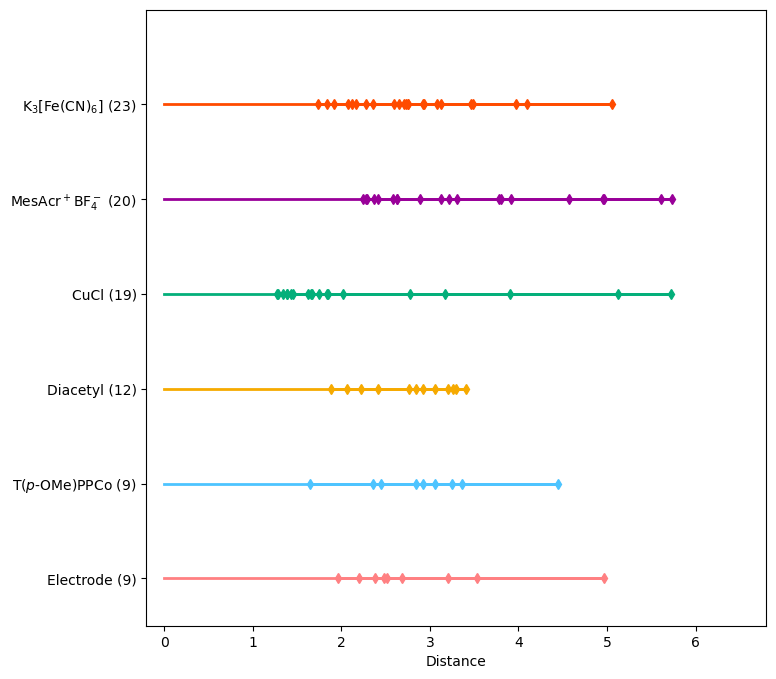

In [17]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot()

x = li_details_2[::-1]
y = labels[::-1]
colours = [e[1] for e in conditions][::-1]

for i in range(6):
    ax.plot([0, x[i][0]], [y[i]]*2, color=colours[i], linewidth=2)
    ax.plot(x[i], [y[i]]*len(x[i]), color=colours[i], linewidth=2,
            marker="d", markersize=5)

ax.set_xlabel("Distance")
ax.set_xlim(-0.2, 6.8)
ax.set_ylim(-0.5, 6)

plt.savefig("distance_details.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
conditions.append(["AllPhenols"])

n = len(df1)
li_numbers.append(n)

ss = metrics.metrics_distance(df1)
li_distance_avg.append(ss[2])
li_distance_max.append(ss[4])

Average coordinate: (-1.0661948875285533e-16, 3.1681219515134155e-16, -2.2847033304183286e-18, -4.112465994752991e-17, 1.523135553612219e-17, 7.006423546616208e-17, 2.4370168857795503e-17, 7.676603190205584e-16, 9.138813321673314e-18, -2.3760914636350617e-16, -5.330974437642767e-16, -1.4012847093232416e-16, 2.5223124767818345e-15, -2.6959499298936276e-16, -7.798454034494561e-16, 0.0, -1.9800762196958847e-17, 1.5840609757567077e-16, 4.2647795501142135e-17, -1.2428786117475707e-15, -9.748067543118201e-17, -1.4622101314677303e-16, 8.529559100228427e-17, 1.3403592871787526e-16, -6.092542214448876e-18, -6.092542214448876e-18, 2.5893304411407724e-17, -4.112465994752991e-17)
Sum of distances: 23354.556883224883
Distance_avg: 5.006335880648421
Nearest SMILES: C=CCc1cc(CC(C)(N)C(=O)O)ccc1O
Distance_max: 18.215869082865968
Farthest SMILES: Oc1ccc(SCCC(F)(F)C(F)(F)C(F)(F)C(F)(F)F)cc1

Describe
count    4665.000000
mean        5.006336
std         1.713835
min         2.403676
25%         3.817418

In [19]:
df_result = pd.DataFrame({"Condition": [e[0] for e in conditions],
                          "Number":li_numbers,
                          "Distance_avg": li_distance_avg,
                          "Distance_max": li_distance_max})
df_result

,Condition,Number,Distance_avg,Distance_max
0,K3FeCN6,23,2.816789,5.054441
1,MesAcr+BF4-,20,3.464991,5.727723
2,CuCl,19,2.245464,5.722111
3,Diacetyl,12,2.776980,3.409037
4,T(p-OMe)PPCo,9,2.927570,4.446373
5,Electrode,9,2.880096,4.962116
6,AllPhenols,4665,5.006336,18.215869


In [20]:
df_result.to_csv("distance.csv", index=False)